In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error
import pickle

In [2]:
data = pd.read_csv('house_price.csv')
data.columns = data.columns.str.strip().str.lower()
data.head()
print(f'Memuat data dari: house_price.csv')
print(f'Jumlah data: {data.shape[0]} Jumlah Kolom: {data.shape[1]}')

Memuat data dari: house_price.csv
Jumlah data: 1000 Jumlah Kolom: 8


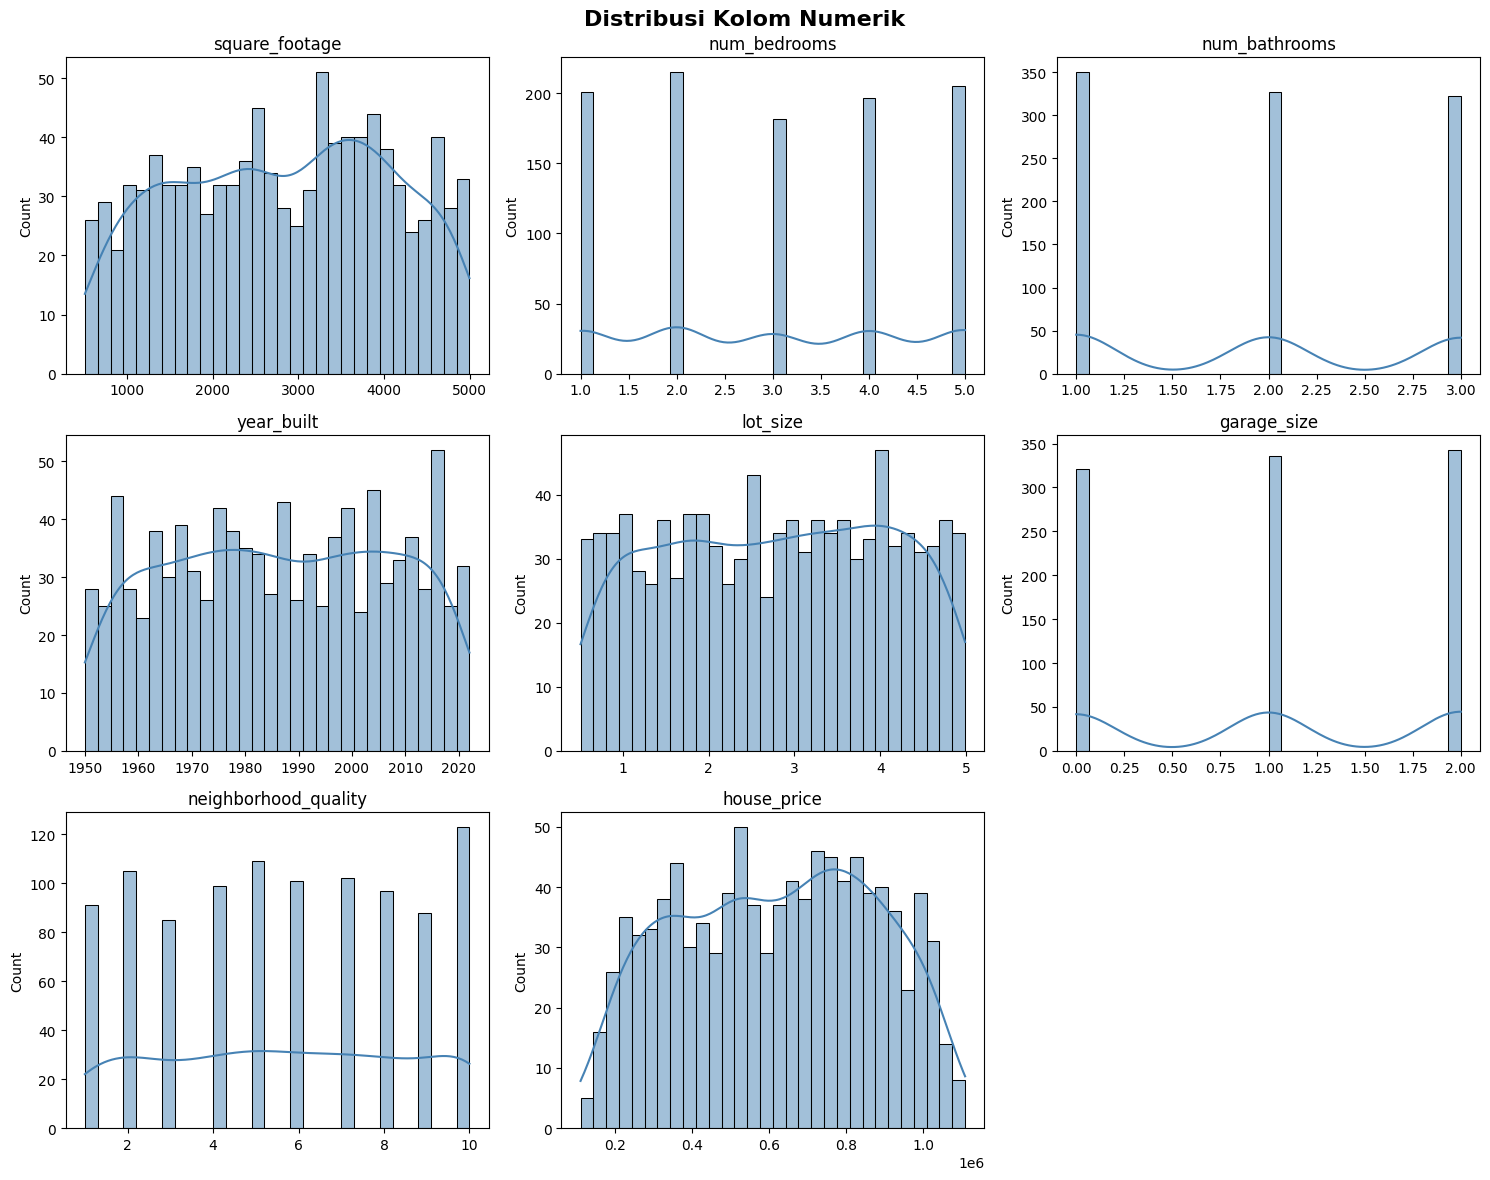

In [3]:
kolom_numerik    = data.select_dtypes(include=['number']).columns.tolist()
kolom_kategorikal = data.select_dtypes(include=['object']).columns.tolist()
if kolom_numerik:
    n_cols = 3
    n_rows = (len(kolom_numerik) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten()
    fig.suptitle('Distribusi Kolom Numerik', fontsize=16, fontweight='bold')

    for i, col in enumerate(kolom_numerik):
        sns.histplot(data[col], bins=30, kde=True, ax=axes[i], color='steelblue')
        axes[i].set_title(col)
        axes[i].set_xlabel('')

        # sembunyikan subplot kosong
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

        plt.tight_layout()
        plt.show()

if kolom_kategorikal:
    n_cols = 3
    n_rows = (len(kolom_kategorikal) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
    fig.suptitle('Distribusi Kolom Kategorikal', fontsize=16, fontweight='bold')

    for i, col in enumerate(kolom_kategorikal):
        order = data[col].value_counts().index
        sns.countplot(data=data, x=col, order=order, ax=axes[i], color='steelblue')
        axes[i].set_title(col)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=30)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

        plt.tight_layout()
        plt.show()

In [4]:
print("Skewness per kolom: ")
print(data.skew().round(2))

kolom_skewed = [col for col in data.columns if col != 'house_price' and not col.endswith('_log')]

for col in kolom_skewed:
        skew = data[col].skew()
        if abs(skew) > 1:
            status = "Highly skewed"
        elif abs(skew) > 0.5:
            status = "Moderately skewed"
        else:
            status = "Normal/OK"
        print(f'{col:30}: {skew:.2f} → {status}')

kolom_highly_skewed = [col for col in kolom_skewed if abs(data[col].skew()) > 1]
print(f'Kolom yang akan ditransformasi: {kolom_highly_skewed}')

Skewness per kolom: 
square_footage         -0.07
num_bedrooms            0.03
num_bathrooms           0.05
year_built             -0.02
lot_size               -0.04
garage_size            -0.04
neighborhood_quality   -0.02
house_price            -0.06
dtype: float64
square_footage                : -0.07 → Normal/OK
num_bedrooms                  : 0.03 → Normal/OK
num_bathrooms                 : 0.05 → Normal/OK
year_built                    : -0.02 → Normal/OK
lot_size                      : -0.04 → Normal/OK
garage_size                   : -0.04 → Normal/OK
neighborhood_quality          : -0.02 → Normal/OK
Kolom yang akan ditransformasi: []


In [5]:
jumlah_awal = len(data)

kolom_numerik = [col for col in data.columns if col != 'admission status']

for col in kolom_numerik:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower_limit = q1 - 1.5*iqr
        upper_limit = q3 + 1.5*iqr

        outlier = data[(data[col] < lower_limit) | (data[col] > upper_limit)].shape[0]
        outlier_persen = outlier / data.shape[0] * 100

        print(f"Number of outliers in {col}: {outlier}")
        print(f"Percentage of outliers in {col}: {outlier_persen:.2f}%")

Number of outliers in square_footage: 0
Percentage of outliers in square_footage: 0.00%
Number of outliers in num_bedrooms: 0
Percentage of outliers in num_bedrooms: 0.00%
Number of outliers in num_bathrooms: 0
Percentage of outliers in num_bathrooms: 0.00%
Number of outliers in year_built: 0
Percentage of outliers in year_built: 0.00%
Number of outliers in lot_size: 0
Percentage of outliers in lot_size: 0.00%
Number of outliers in garage_size: 0
Percentage of outliers in garage_size: 0.00%
Number of outliers in neighborhood_quality: 0
Percentage of outliers in neighborhood_quality: 0.00%
Number of outliers in house_price: 0
Percentage of outliers in house_price: 0.00%


In [6]:
target = 'house_price'
y = data[target]
x = data.drop(columns=[target])

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [8]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [9]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [10]:
x_pred = model.predict(x_test_scaled)
mse = mean_squared_error(y_test, x_pred)
r2 = r2_score(y_test, x_pred)
rmse = root_mean_squared_error(y_test, x_pred)
mae = mean_absolute_error(y_test, x_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Error: {mae:.2f}')

Mean Squared Error: 394154497.04
R² Score: 0.99
Root Mean Squared Error: 19853.32
Mean Absolute Error: 16106.27


In [11]:
y_pred = model.predict(x_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Error: {mae:.2f}')

Mean Squared Error: 394154497.04
R² Score: 0.99
Root Mean Squared Error: 19853.32
Mean Absolute Error: 16106.27


In [12]:
filename = 'house_price_model.sav'
pickle.dump(model, open(filename, 'wb'))
pickle.dump(scaler, open('scaler.sav', 'wb'))